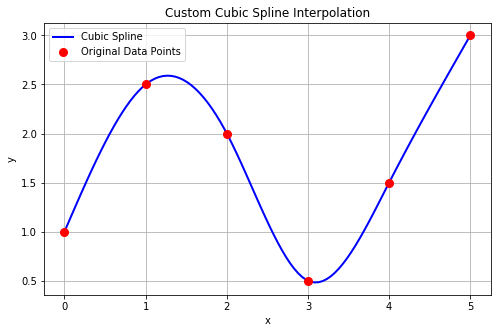

In [2]:
import matplotlib.pyplot as plt

# --- Helper Function: Thomas Algorithm ---
def thomas_algorithm(a, b, c, d):
    """
    Solves a tridiagonal system of equations.
    a: lower diagonal (0-indexed, a[0] is not used)
    b: main diagonal
    c: upper diagonal (c[-1] is not used)
    d: right-hand side
    """
    n = len(d)
    c_star = [0.0] * n
    d_star = [0.0] * n
    
    # Forward sweep
    c_star[0] = c[0] / b[0]
    d_star[0] = d[0] / b[0]
    
    for i in range(1, n):
        m = 1.0 / (b[i] - a[i] * c_star[i-1])
        if i < n - 1:
            c_star[i] = c[i] * m
        d_star[i] = (d[i] - a[i] * d_star[i-1]) * m
        
    # Back substitution
    x = [0.0] * n
    x[-1] = d_star[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = d_star[i] - c_star[i] * x[i+1]
        
    return x

def evaluate_spline(x_eval, x, y, M, h):
    """Evaluates the spline at a specific new point."""
    # Find the correct interval [x_i, x_{i+1}]
    n = len(x)
    interval = 0
    for i in range(n - 1):
        if x[i] <= x_eval <= x[i+1]:
            interval = i
            break
            
    i = interval
    # Calculate the coefficients for the cubic polynomial
    a_coef = (x[i+1] - x_eval) / h[i]
    b_coef = (x_eval - x[i]) / h[i]
    c_coef = (a_coef**3 - a_coef) * (h[i]**2) / 6.0
    d_coef = (b_coef**3 - b_coef) * (h[i]**2) / 6.0
    
    # Evaluate polynomial
    y_eval = a_coef * y[i] + b_coef * y[i+1] + c_coef * M[i] + d_coef * M[i+1]
    return y_eval

# ==========================================
# Main Assignment Steps
# ==========================================

# Step 1: Define Known Data Points
# We will use some sample points that form a recognizable curve.
x_data = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
y_data = [1.0, 2.5, 2.0, 0.5, 1.5, 3.0]
N = len(x_data)

# Step 2: Calculate Step Sizes
# The array h stores the distance between consecutive x-coordinates
h = [x_data[i+1] - x_data[i] for i in range(N - 1)]

# Step 3: Set Up and Solve the Tridiagonal System
# We have N-2 unknown internal second derivatives (M_1 to M_{N-2}).
# M_0 and M_{N-1} are 0 due to natural boundary conditions.
num_unknowns = N - 2
A = [0.0] * num_unknowns  # Lower diagonal
B = [0.0] * num_unknowns  # Main diagonal
C = [0.0] * num_unknowns  # Upper diagonal
D = [0.0] * num_unknowns  # RHS vector

for i in range(1, N - 1):
    idx = i - 1  # Index in the tridiagonal system arrays
    
    # Smoothness condition equations
    B[idx] = (h[i-1] + h[i]) / 3.0
    D[idx] = (y_data[i+1] - y_data[i]) / h[i] - (y_data[i] - y_data[i-1]) / h[i-1]
    
    if i > 1:
        A[idx] = h[i-1] / 6.0
    if i < N - 2:
        C[idx] = h[i] / 6.0

# Solve the matrix system using the Thomas Algorithm
M_internal = thomas_algorithm(A, B, C, D)

# The second derivatives M at the data points, applying M_0 = M_n = 0
M = [0.0] + M_internal + [0.0]

# Step 4: Evaluate the Spline at New Points
# Create a dense array of x values for smooth plotting
x_dense = []
num_eval_points = 100
step = (x_data[-1] - x_data[0]) / (num_eval_points - 1)
for i in range(num_eval_points):
    x_dense.append(x_data[0] + i * step)

y_dense = [evaluate_spline(xe, x_data, y_data, M, h) for xe in x_dense]

# Plot the Results
plt.figure(figsize=(8, 5))
plt.plot(x_dense, y_dense, label="Cubic Spline", color="blue", linewidth=2)
plt.plot(x_data, y_data, 'ro', label="Original Data Points", markersize=8)
plt.title("Custom Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()